# DICIE Pipeline Walkthrough — `src/docie/`

This notebook is a **complete, stage-by-stage showcase** of the Document Image Classification and Information Extraction (DICIE) chain implemented in `src/docie/`.

It follows Fig. 1 from Raj, Dickinson & Fung, *Document Classification and Information Extraction framework for Insurance Applications*:

```
Input (PDF / page images / text)
  → Stage 1  Document Processing
  → Stage 2  Document Classification  (+ page aggregation)
  → Stage 3  Information Extraction
  → Output   Aggregated prediction → response / downstream
```

| Section | What you will see |
|---------|-------------------|
| 0 | Setup, config, demo knobs |
| 1 | Application profiles & taxonomies |
| 2 | Fixture corpus overview |
| 3 | Stage 1 — process text → page image + OCR text |
| 4 | Stage 1 — process a multi-line PDF |
| 5 | Stage 2 — per-page classify + majority aggregation |
| 6 | Stage 2 — prefer-non-`other` tie-break |
| 7 | Stage 3 — heuristic field extraction |
| 8 | Stage 4 — aggregate, review flags, response payload |
| 9 | Full `DociePipeline` — salvage LOG |
| 10 | Full `DociePipeline` — medical HCFA |
| 11 | Batch JSONL via `run_file` |
| 12 | Downstream sink + optional model backends |
| 13 | Contrast with `src/pipeline/` memo chain |

> **No API keys required.** The default path uses keyword heuristics + regex extraction.  
> OCR (`pip install -e ".[ocr]"` + system Tesseract) is optional; this notebook defaults to `RUN_OCR = False` so it runs cleanly on CPU without Tesseract.

Canonical docs: [`docs/docie_pipeline.md`](../docie_pipeline.md), [`docs/architecture.md`](../architecture.md).

## 0. Setup

Put the repo root on `sys.path`, load `Config`, and create a demo output directory under `data/notebook_demo/docie/`.

In [1]:
from __future__ import annotations

import json
import logging
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import Image as IPyImage
from IPython.display import Markdown, display

# Resolve repo root whether the kernel cwd is repo root or notebooks/
CWD = Path.cwd().resolve()
# Walk up from docs/notebooks/ (or notebooks/) until pyproject.toml is found.
REPO_ROOT = next(
    (p for p in (CWD, *CWD.parents) if (p / "pyproject.toml").exists()),
    None,
)
assert REPO_ROOT is not None, f"Could not find repo root from {CWD}"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.docie import DociePipeline, process_document
from src.docie.aggregate import aggregate_prediction, push_downstream
from src.docie.applications import list_applications, load_application
from src.docie.classify import (
    aggregate_page_predictions,
    classify_document,
    classify_page_text,
)
from src.docie.extract import extract_information, heuristic_extract
from src.docie.pipeline import run_file
from src.docie.processing import process_document_input
from src.docie.types import PageClassification
from src.utils.config import Config
from src.utils.io import load_jsonl, read_json

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

cfg = Config.load()

# --- Demo knobs ---
RUN_OCR = False  # set True if pytesseract + Tesseract are installed
DPI = 200        # lower than production 300 for faster PDF renders in the notebook

DEMO = REPO_ROOT / "data" / "notebook_demo" / "docie"
CACHE = DEMO / "cache"
DEMO.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

FIXTURES = REPO_ROOT / "tests" / "fixtures" / "sample_docie_documents.jsonl"

print(f"repo:     {REPO_ROOT}")
print(f"python:   {sys.version.split()[0]}")
print(f"apps:     {list_applications()}")
print(f"RUN_OCR:  {RUN_OCR}  DPI={DPI}")
print(f"demo →    {DEMO}")
print(f"fixtures: {FIXTURES.exists()}")

repo:     /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer
python:   3.11.15
apps:     ['acord', 'medical_bills', 'salvage_claims']
RUN_OCR:  False  DPI=200
demo →    /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/docie
fixtures: True


### Helper — pretty-print nested prediction dicts

In [2]:
def show_json(obj, *, title: str | None = None, max_chars: int = 4000) -> None:
    """Display a dict / dataclass dump as a fenced JSON block."""
    if hasattr(obj, "to_dict"):
        obj = obj.to_dict()
    text = json.dumps(obj, indent=2, ensure_ascii=False, default=str)
    if len(text) > max_chars:
        text = text[:max_chars] + "\n… (truncated)"
    if title:
        display(Markdown(f"**{title}**"))
    display(Markdown(f"```json\n{text}\n```"))


def show_page_image(page, *, title: str | None = None) -> None:
    path = Path(page.image_path)
    if title:
        display(Markdown(f"**{title}** — `{path.name}` ({page.width}×{page.height}, dpi={page.dpi}, ocr=`{page.ocr_backend}`)"))
    if path.exists():
        display(IPyImage(filename=str(path), width=min(520, page.width)))
    else:
        print(f"missing page image: {path}")

## 1. Application profiles & taxonomies

DICIE is **application-scoped**. Each profile (loaded from YAML under `taxonomy/`) defines:

- **labels** — document classes for Stage 2
- **aliases** — keyword cues used by the heuristic classifier
- **extraction_fields** — Stage 3 targets
- **business rules** — e.g. prefer non-`other` on ties, human-review confidence threshold

| Application | Classes | Extracted fields |
|-------------|---------|------------------|
| `medical_bills` | `hcfa`, `ub04`, `other` | claim_id, name, dob, patient_id, address |
| `salvage_claims` | `log`, `sales`, `other` | claim_id, vin, year, make, model |
| `acord` | ACORD intake taxonomy | claim / policy / loss fields |

In [3]:
profiles = {name: load_application(name) for name in list_applications()}

rows = []
for name, profile in profiles.items():
    rows.append(
        {
            "application": profile.name,
            "n_labels": len(profile.labels),
            "labels": ", ".join(profile.labels[:8]) + ("…" if len(profile.labels) > 8 else ""),
            "extraction_fields": ", ".join(profile.extraction_fields),
            "prefer_non_other": profile.prefer_non_other,
            "review_threshold": profile.review_confidence_threshold,
            "taxonomy": str(profile.taxonomy_path.relative_to(REPO_ROOT)) if profile.taxonomy_path else "—",
        }
    )

display(pd.DataFrame(rows))

for app in ("salvage_claims", "medical_bills"):
    p = profiles[app]
    display(Markdown(f"### `{app}`\n\n{p.description}\n"))
    alias_df = pd.DataFrame(
        [{"label": lab, "aliases": ", ".join(p.aliases.get(lab, []))} for lab in p.labels]
    )
    display(alias_df)

,application,n_labels,labels,extraction_fields,prefer_non_other,review_threshold,taxonomy
0,acord,9,"application_commercial, application_personal, ...","claim_id, policy_number, policyholder_name, da...",True,0.55,taxonomy/acord_form_categories.yaml
1,medical_bills,3,"hcfa, ub04, other","claim_id, name, dob, patient_id, address",True,0.55,taxonomy/medical_bills.yaml
2,salvage_claims,3,"log, sales, other","claim_id, vin, year, make, model",True,0.55,taxonomy/salvage_claims.yaml


### `salvage_claims`

Classify bank-issued letters of guarantee and related salvage attachments, then extract vehicle identifiers for total-loss automobile claims.


,label,aliases
0,log,"LOG, Letter of Guarantee, Letter Of Guarantee,..."
1,sales,"SALES, Sales Receipt, Sales Tax, Bill of Sale"
2,other,"OTHER, Salvage Other"


### `medical_bills`

Medical bill classification and claimant information extraction for automobile insurance casualty claims review and re-pricing.


,label,aliases
0,hcfa,"HCFA, CMS-1500, CMS 1500, Health Care Finance ..."
1,ub04,"UB, UB-04, UB04, Uniform Billing, CMS-1450"
2,other,"Non-standard, OTHER, Medical Other"


Inspect the raw YAML that backs the salvage profile:

In [4]:
salvage_yaml = yaml.safe_load(
    (REPO_ROOT / "taxonomy" / "salvage_claims.yaml").read_text(encoding="utf-8")
)
show_json(salvage_yaml, title="taxonomy/salvage_claims.yaml")

**taxonomy/salvage_claims.yaml**

```json
{
  "application": "salvage_claims",
  "description": "Classify bank-issued letters of guarantee and related salvage attachments, then extract vehicle identifiers for total-loss automobile claims.\n",
  "categories": [
    {
      "label": "log",
      "aliases": [
        "LOG",
        "Letter of Guarantee",
        "Letter Of Guarantee",
        "Guarantee"
      ],
      "description": "Bank-issued letter of guarantee for loan/lease payoff on a total-loss vehicle."
    },
    {
      "label": "sales",
      "aliases": [
        "SALES",
        "Sales Receipt",
        "Sales Tax",
        "Bill of Sale"
      ],
      "description": "Salvage sales receipt or sales-tax documentation."
    },
    {
      "label": "other",
      "aliases": [
        "OTHER",
        "Salvage Other"
      ],
      "description": "Other salvage-claim attachments that are neither LOG nor sales receipt."
    }
  ],
  "extraction_fields": [
    "claim_id",
    "vin",
    "year",
    "make",
    "model"
  ],
  "business_rules": {
    "prefer_non_other": true,
    "review_confidence_threshold": 0.55
  }
}
```

## 2. Fixture corpus

`tests/fixtures/sample_docie_documents.jsonl` ships six labeled text documents — three medical, three salvage — covering the positive classes and an `other` negative for each application.

In [5]:
fixture_rows = load_jsonl(FIXTURES)
fixture_df = pd.DataFrame(
    [
        {
            "record_id": r["record_id"],
            "application": r["application"],
            "document_type": r["document_type"],
            "chars": len(r["text"]),
            "preview": r["text"].splitlines()[0][:60],
        }
        for r in fixture_rows
    ]
)
display(fixture_df)

by_id = {r["record_id"]: r for r in fixture_rows}
LOG_TEXT = by_id["sal-log-001"]["text"]
HCFA_TEXT = by_id["med-hcfa-001"]["text"]

display(Markdown("### Sample — salvage Letter of Guarantee"))
print(LOG_TEXT)
display(Markdown("### Sample — medical HCFA / CMS-1500"))
print(HCFA_TEXT)

,record_id,application,document_type,chars,preview
0,med-hcfa-001,medical_bills,hcfa,292,HCFA CMS-1500 HEALTH INSURANCE CLAIM FORM
1,med-ub04-002,medical_bills,ub04,226,UB-04 UNIFORM BILLING FORM CMS-1450
2,med-other-003,medical_bills,other,155,COMMUNITY CLINIC STATEMENT
3,sal-log-001,salvage_claims,log,253,LETTER OF GUARANTEE
4,sal-sales-002,salvage_claims,sales,203,SALVAGE SALES RECEIPT
5,sal-other-003,salvage_claims,other,120,TOWING INVOICE


### Sample — salvage Letter of Guarantee

LETTER OF GUARANTEE
First National Bank Lienholder Services
This letter guarantees that the insurer reimbursement will pay the bank first.
Claim Number: CLM-2024-100200
VIN: 1HGCM82633A004352
Year: 2018
Make: Honda
Model: Accord
Payoff Amount: $4,250.00


### Sample — medical HCFA / CMS-1500

HCFA CMS-1500 HEALTH INSURANCE CLAIM FORM
Physician or Supplier Information
Patient Name: Jane Q Public
Date of Birth: 03/14/1988
Patient ID: PID-778812
Claim Number: CLM-2024-551122
Address: 100 Oak Avenue, Madison WI 53703
Carrier Name: American Family
Diagnosis and procedure codes follow.


## 3. Stage 1 — Document Processing (text input)

`process_document_input` is the image-first entry point:

1. Accept PDF, image, plain text, or empty
2. Render / preprocess to grayscale page PNG(s) under a cache directory
3. Optionally OCR (PyTesseract) → word tokens with 0–1000 normalized boxes
4. Return a `ProcessedDocument` ready for classify + extract

**Text inputs are rendered to a page image** so the rest of the chain stays image-first (paper §V.C).

record_id:   walkthrough-log
source_kind: text
n_pages:     1
application: salvage_claims

--- full_text ---
LETTER OF GUARANTEE
First National Bank Lienholder Services
This letter guarantees that the insurer reimbursement will pay the bank first.
Claim Number: CLM-2024-100200
VIN: 1HGCM82633A004352
Year: 2018
Make: Honda
Model: Accord
Payoff Amount: $4,250.00


**Stage 1 page image (text → rendered PNG)** — `walkthrough-log__5750df1a2104a5cc__page_000.png` (1000×1200, dpi=200, ocr=`rendered_text`)

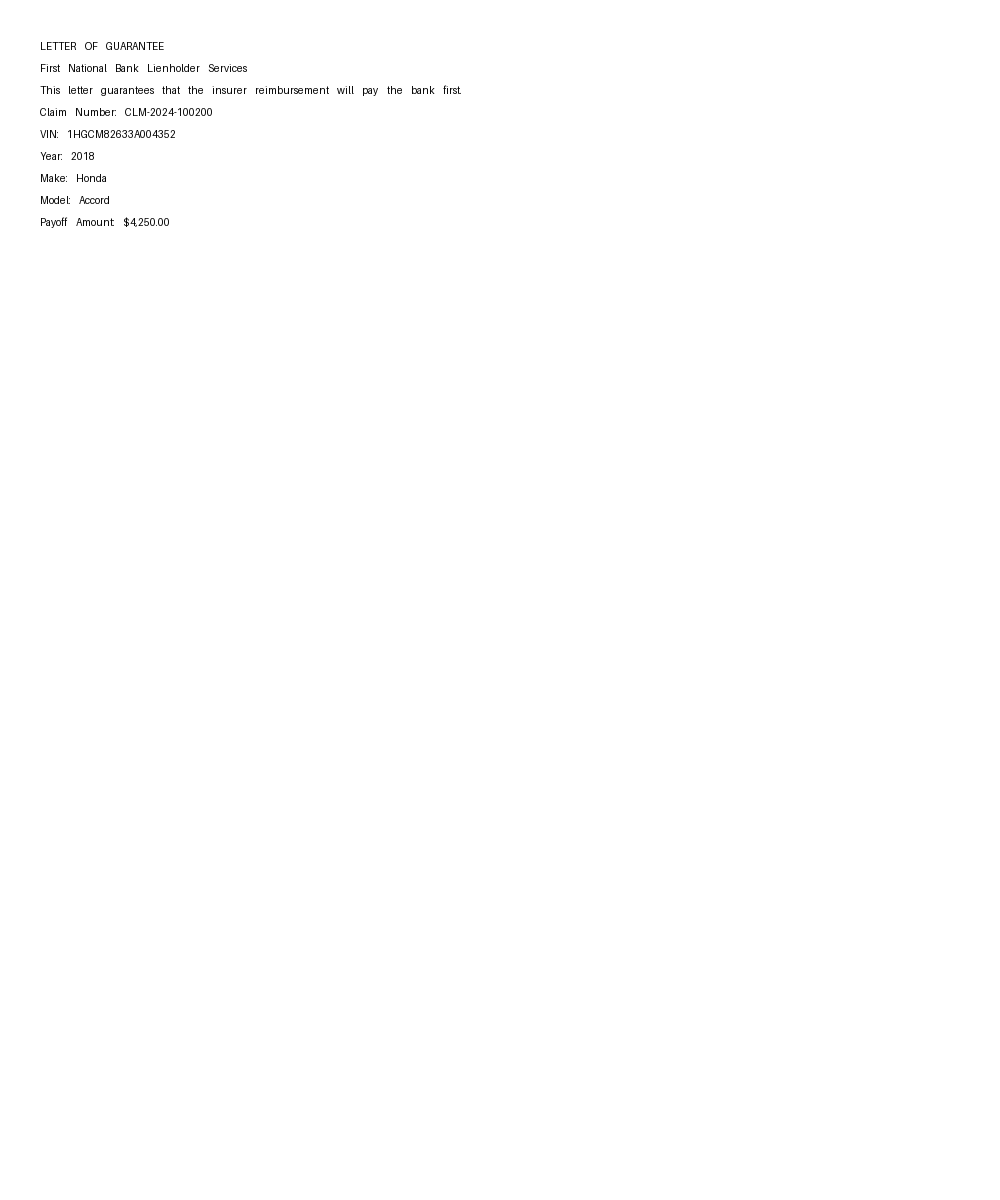

**PageImage summary**

```json
{
  "page_index": 0,
  "image_path": "/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/docie/cache/pages/walkthrough-log__5750df1a2104a5cc__page_000.png",
  "width": 1000,
  "height": 1200,
  "dpi": 200,
  "grayscale": true,
  "ocr_backend": "rendered_text",
  "n_words": 34,
  "text_preview": "LETTER OF GUARANTEE\nFirst National Bank Lienholder Services\nThis letter guarantees that the insurer reimbursement will pay the bank first.\nClaim Number: CLM-2024-100200\nVIN: 1HGCM82633A004352\nYear: 20"
}
```

In [6]:
salvage = load_application("salvage_claims")

processed_log = process_document_input(
    record_id="walkthrough-log",
    text=LOG_TEXT,
    cache_dir=CACHE / "pages",
    application="salvage_claims",
    dpi=DPI,
    grayscale=True,
    run_ocr=RUN_OCR,
    metadata={"fixture": "sal-log-001", "stage": "walkthrough"},
)

print(f"record_id:   {processed_log.record_id}")
print(f"source_kind: {processed_log.source_kind}")
print(f"n_pages:     {len(processed_log.pages)}")
print(f"application: {processed_log.application}")
print()
print("--- full_text ---")
print(processed_log.full_text)

page0 = processed_log.pages[0]
show_page_image(page0, title="Stage 1 page image (text → rendered PNG)")
show_json(
    {
        "page_index": page0.page_index,
        "image_path": str(page0.image_path),
        "width": page0.width,
        "height": page0.height,
        "dpi": page0.dpi,
        "grayscale": page0.grayscale,
        "ocr_backend": page0.ocr_backend,
        "n_words": len(page0.words),
        "text_preview": page0.text[:200],
    },
    title="PageImage summary",
)

## 4. Stage 1 — Document Processing (PDF input)

PDFs are rasterized with PyMuPDF at the configured DPI. Even with `run_ocr=False`, the pipeline can fall back to the PDF text layer (`pymupdf_text`) when present — useful for born-digital forms.

wrote /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/docie/sample_letter_of_guarantee.pdf
source_kind: pdf
n_pages:     2


**PDF page 0** — `walkthrough-pdf__af5ff734cb6ce3d7__page_000.png` (1654×2339, dpi=200, ocr=`pymupdf_text`)

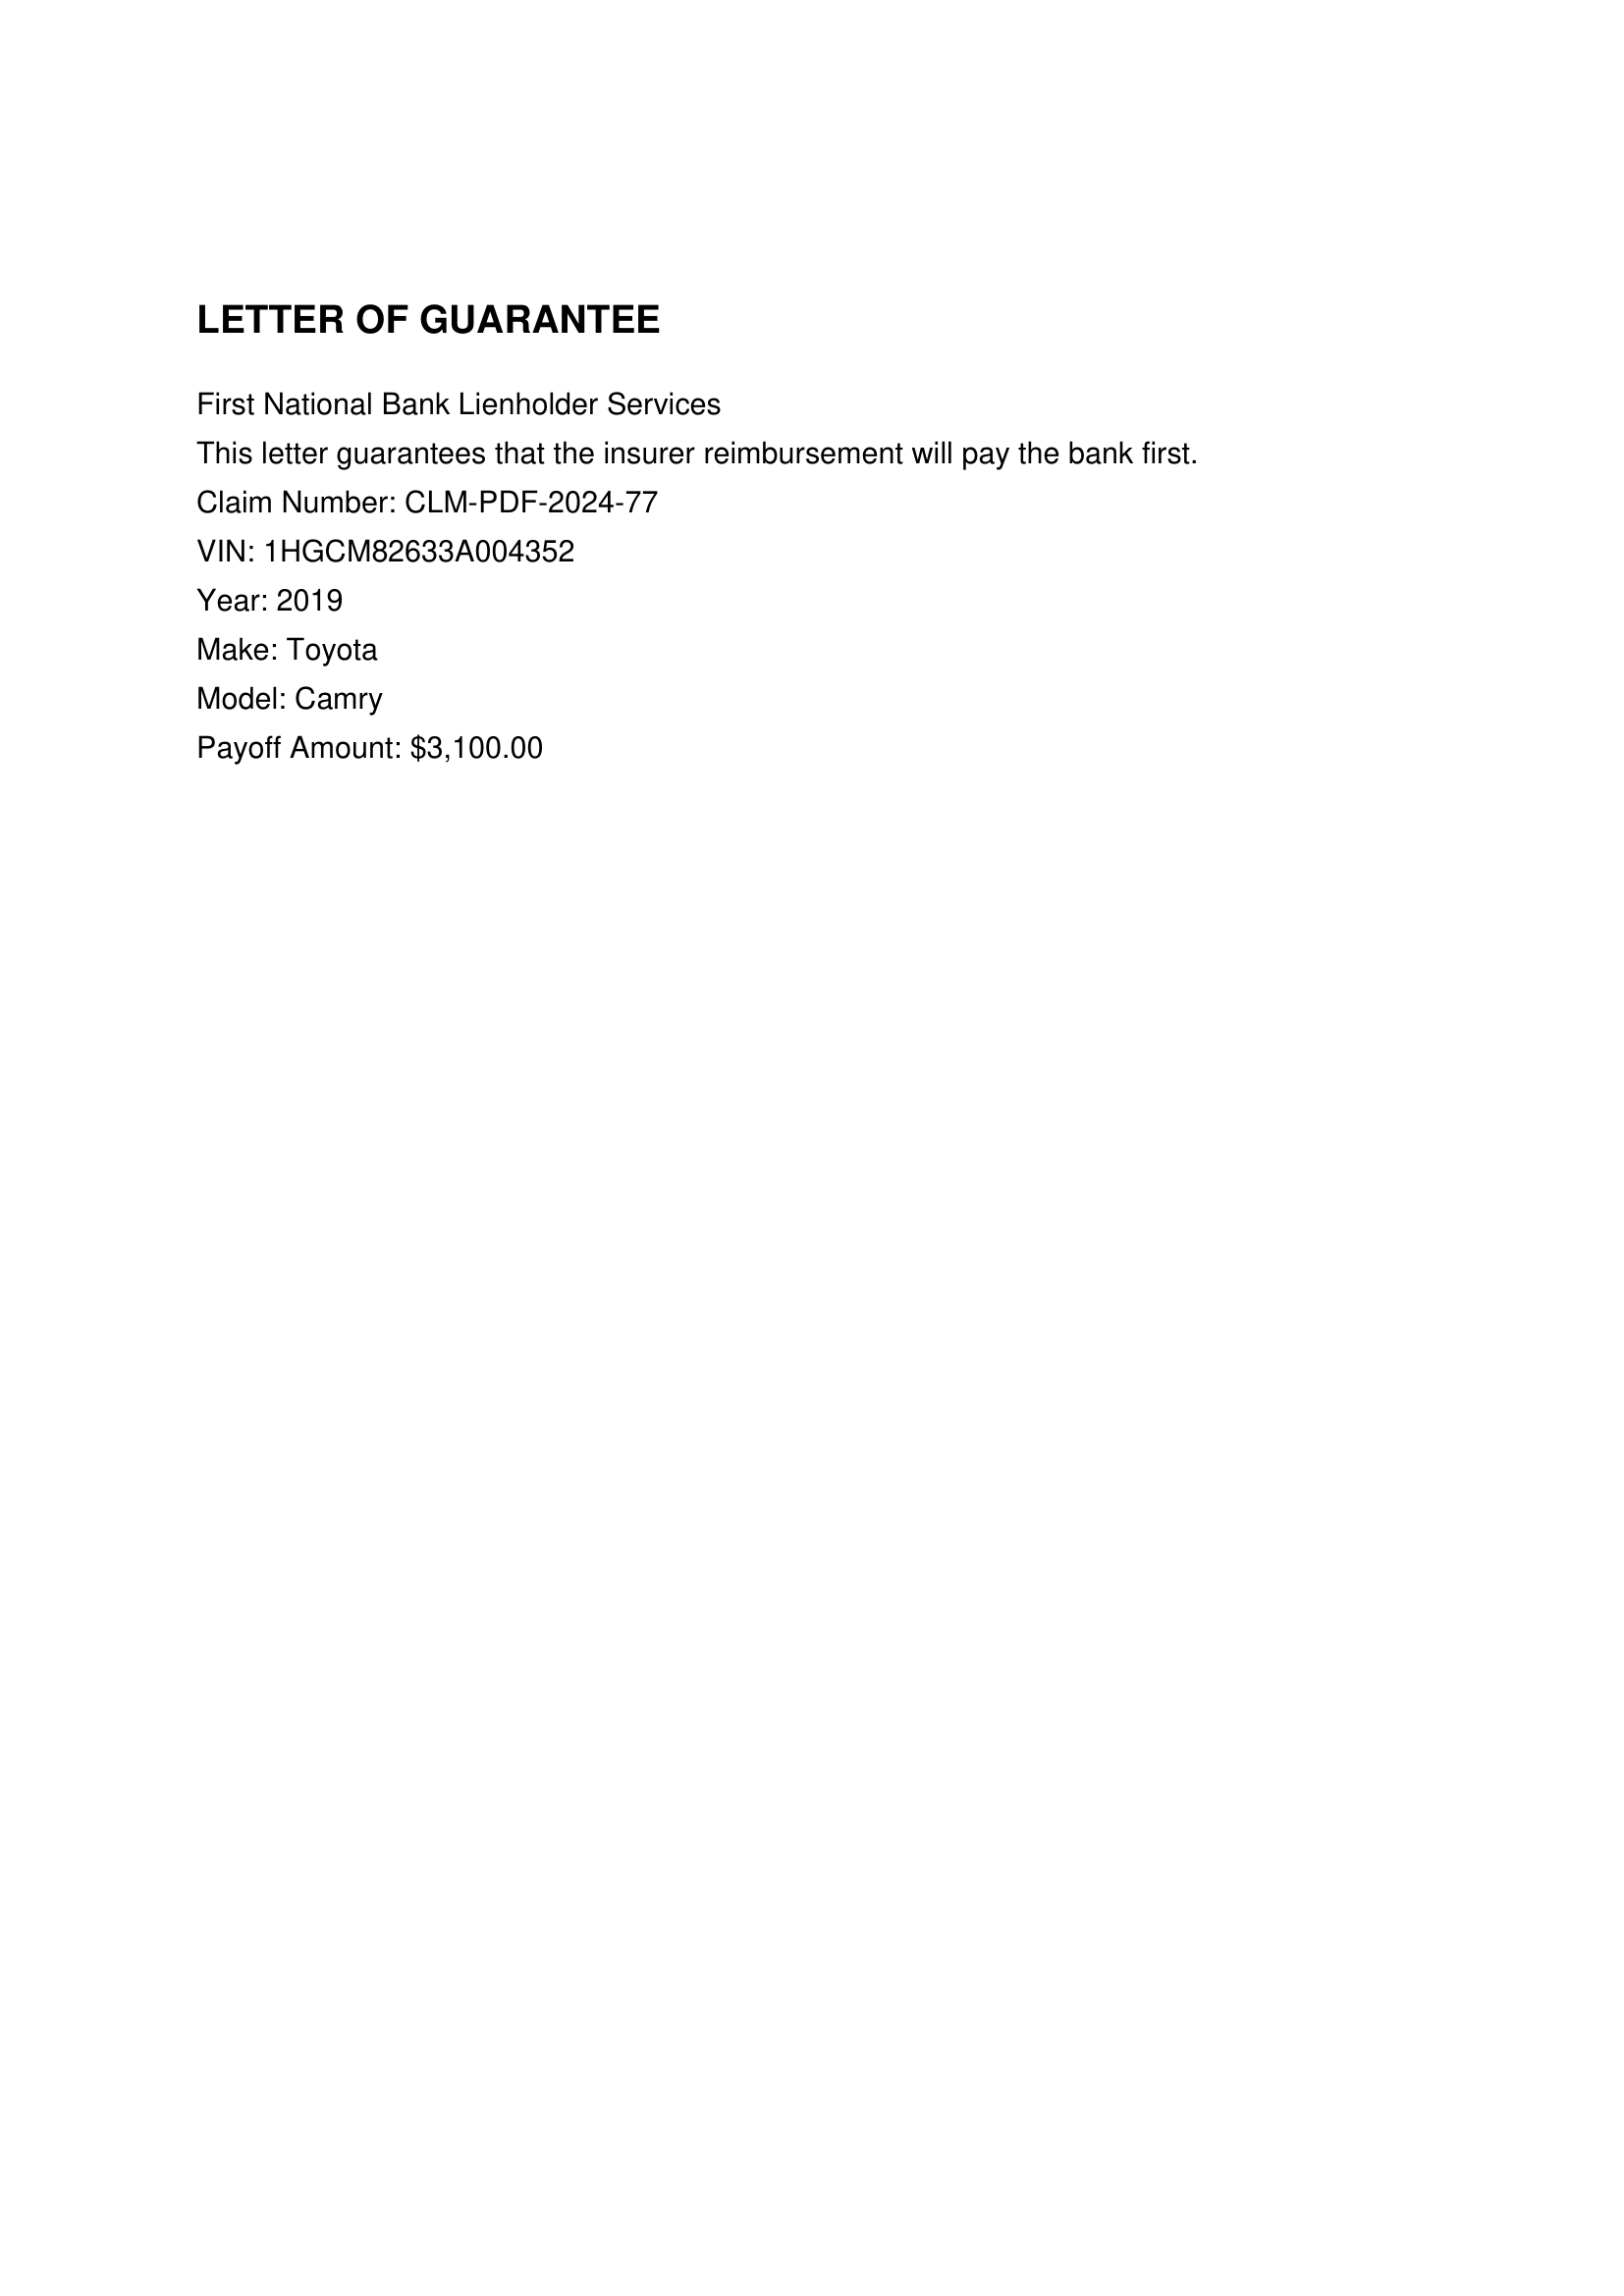

  ocr_backend='pymupdf_text'  text_chars=253


**PDF page 1** — `walkthrough-pdf__af5ff734cb6ce3d7__page_001.png` (1654×2339, dpi=200, ocr=`pymupdf_text`)

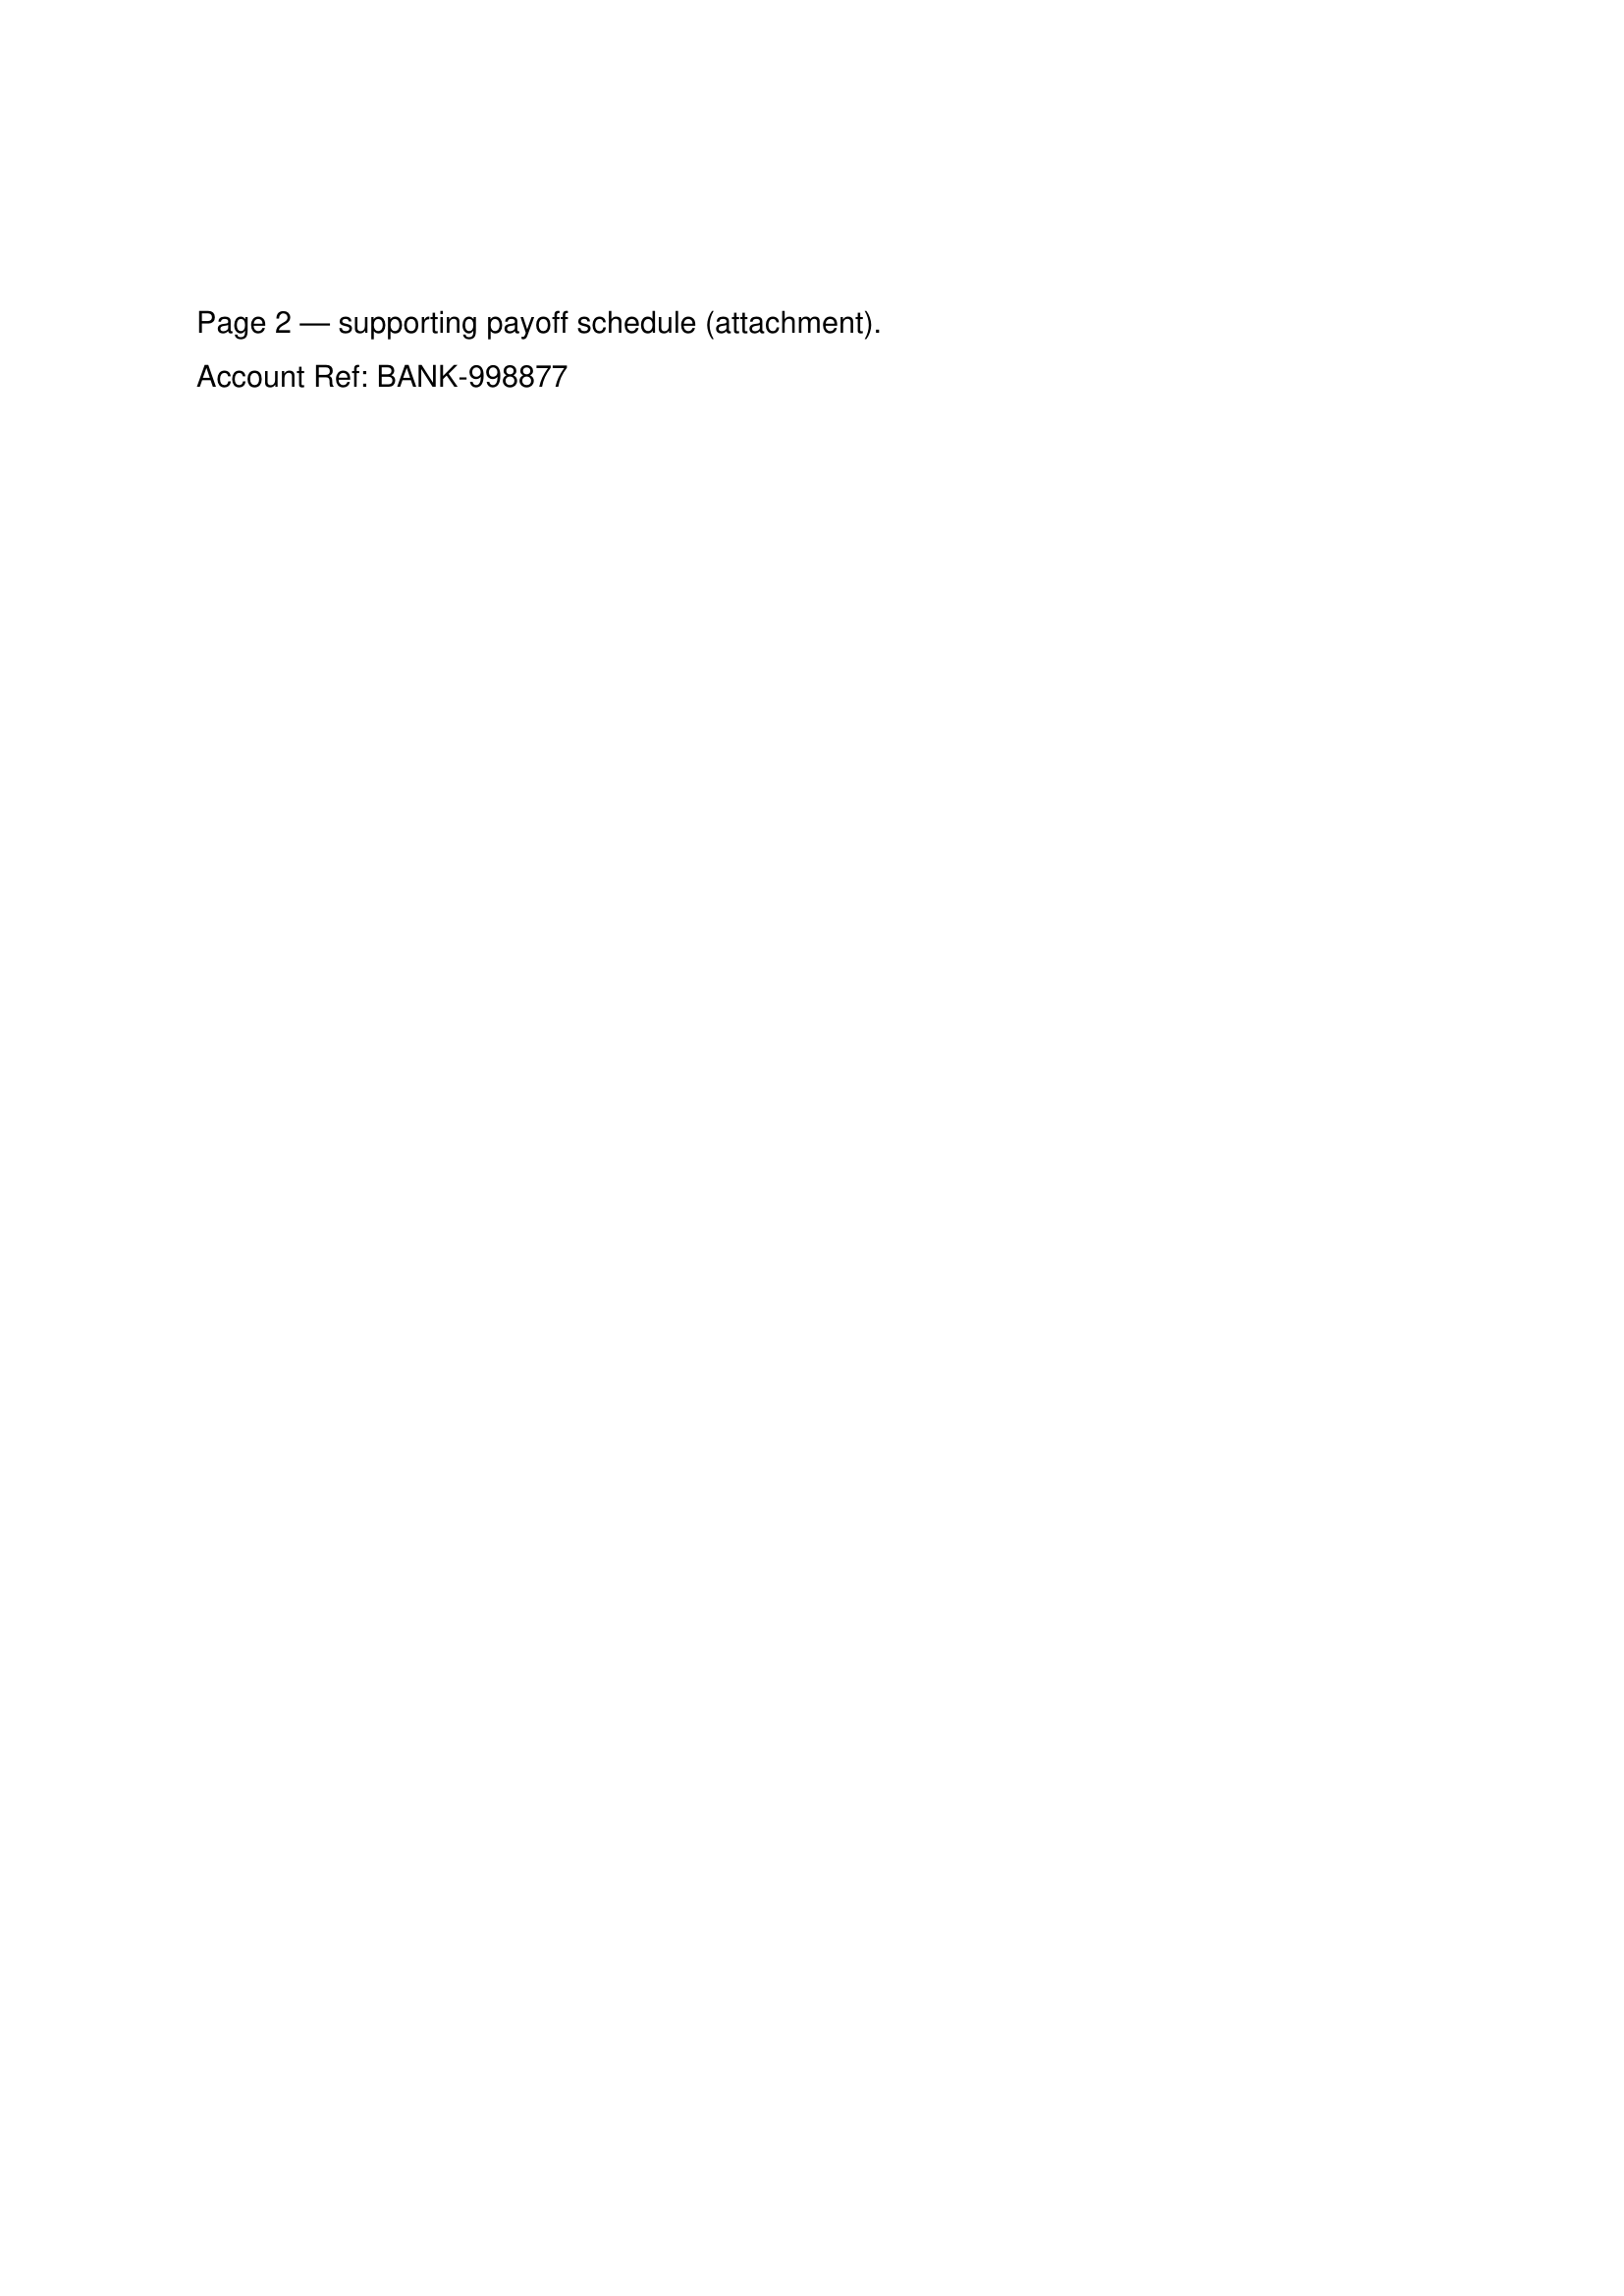

  ocr_backend='pymupdf_text'  text_chars=74


### PDF full_text (text-layer / OCR)

LETTER OF GUARANTEE
First National Bank Lienholder Services
This letter guarantees that the insurer reimbursement will pay the bank first.
Claim Number: CLM-PDF-2024-77
VIN: 1HGCM82633A004352
Year: 2019
Make: Toyota
Model: Camry
Payoff Amount: $3,100.00

Page 2 — supporting payoff schedule (attachment).
Account Ref: BANK-998877


In [7]:
from reportlab.pdfgen import canvas

pdf_path = DEMO / "sample_letter_of_guarantee.pdf"
c = canvas.Canvas(str(pdf_path))
c.setFont("Helvetica-Bold", 14)
c.drawString(72, 720, "LETTER OF GUARANTEE")
c.setFont("Helvetica", 11)
lines = [
    "First National Bank Lienholder Services",
    "This letter guarantees that the insurer reimbursement will pay the bank first.",
    "Claim Number: CLM-PDF-2024-77",
    "VIN: 1HGCM82633A004352",
    "Year: 2019",
    "Make: Toyota",
    "Model: Camry",
    "Payoff Amount: $3,100.00",
]
y = 690
for line in lines:
    c.drawString(72, y, line)
    y -= 18
c.showPage()
c.setFont("Helvetica", 11)
c.drawString(72, 720, "Page 2 — supporting payoff schedule (attachment).")
c.drawString(72, 700, "Account Ref: BANK-998877")
c.save()
print(f"wrote {pdf_path}")

processed_pdf = process_document_input(
    record_id="walkthrough-pdf",
    pdf_path=pdf_path,
    cache_dir=CACHE / "pages",
    application="salvage_claims",
    dpi=DPI,
    run_ocr=RUN_OCR,
)

print(f"source_kind: {processed_pdf.source_kind}")
print(f"n_pages:     {len(processed_pdf.pages)}")
for p in processed_pdf.pages:
    show_page_image(p, title=f"PDF page {p.page_index}")
    print(f"  ocr_backend={p.ocr_backend!r}  text_chars={len(p.text)}")

display(Markdown("### PDF full_text (text-layer / OCR)"))
print(processed_pdf.full_text)

## 5. Stage 2 — Document Classification

Classification is **page-first**, then aggregated:

1. `classify_page_text` — keyword / alias scoring per class (backend `heuristic_text`)
2. Optional ViT when `vit_model_dir` has matching labels (blended 50/50 with text)
3. `aggregate_page_predictions` — confidence-weighted majority vote → `ClassificationResult`

Below we score every fixture document with the matching application profile.

In [8]:
classify_rows = []
for row in fixture_rows:
    profile = load_application(row["application"])
    pred = classify_page_text(row["text"], profile)
    classify_rows.append(
        {
            "record_id": row["record_id"],
            "gold": row["document_type"],
            "pred": pred.label,
            "confidence": round(pred.confidence, 3),
            "correct": pred.label == row["document_type"],
            "top_scores": {
                k: round(v, 3)
                for k, v in sorted(pred.scores.items(), key=lambda kv: -kv[1])[:3]
            },
            "backend": pred.backend,
        }
    )

cls_df = pd.DataFrame(classify_rows)
display(cls_df)
print(f"accuracy on fixtures: {cls_df['correct'].mean():.0%}")

display(Markdown("### Per-page scores — Letter of Guarantee"))
log_page = classify_page_text(LOG_TEXT, salvage)
show_json(log_page, title="PageClassification")

,record_id,gold,pred,confidence,correct,top_scores,backend
0,med-hcfa-001,hcfa,hcfa,0.95,True,"{'hcfa': 1.0, 'ub04': 0.111, 'other': 0.0}",heuristic_text
1,med-ub04-002,ub04,ub04,0.95,True,"{'ub04': 1.0, 'hcfa': 0.0, 'other': 0.0}",heuristic_text
2,med-other-003,other,other,0.61,True,"{'other': 0.35, 'hcfa': 0.0, 'ub04': 0.0}",heuristic_text
3,sal-log-001,log,log,0.82,True,"{'log': 0.7, 'sales': 0.0, 'other': 0.0}",heuristic_text
4,sal-sales-002,sales,sales,0.95,True,"{'sales': 1.2, 'log': 0.0, 'other': 0.0}",heuristic_text
5,sal-other-003,other,other,0.61,True,"{'other': 0.35, 'log': 0.0, 'sales': 0.0}",heuristic_text


accuracy on fixtures: 100%


### Per-page scores — Letter of Guarantee

**PageClassification**

```json
{
  "page_index": 0,
  "label": "log",
  "confidence": 0.8200000000000001,
  "backend": "heuristic_text",
  "scores": {
    "log": 0.7,
    "sales": 0.0,
    "other": 0.0
  }
}
```

### Document-level aggregation on the 2-page PDF

`classify_document` runs Stage 2 over every page of a `ProcessedDocument` and returns one document label.

In [9]:
pdf_classification = classify_document(processed_pdf, salvage)
show_json(pdf_classification, title="ClassificationResult (2-page PDF)")

page_df = pd.DataFrame(
    [
        {
            "page": p.page_index,
            "label": p.label,
            "confidence": round(p.confidence, 3),
            "backend": p.backend,
        }
        for p in pdf_classification.page_predictions
    ]
)
display(page_df)
print(
    f"document label={pdf_classification.label!r}  "
    f"confidence={pdf_classification.confidence:.3f}  "
    f"aggregation={pdf_classification.aggregation!r}"
)

**ClassificationResult (2-page PDF)**

```json
{
  "label": "log",
  "confidence": 0.8200000000000001,
  "backend": "heuristic_text",
  "aggregation": "confidence_weighted_majority",
  "page_predictions": [
    {
      "page_index": 0,
      "label": "log",
      "confidence": 0.8200000000000001,
      "backend": "heuristic_text",
      "scores": {
        "log": 0.7,
        "sales": 0.0,
        "other": 0.0
      }
    },
    {
      "page_index": 1,
      "label": "log",
      "confidence": 0.46,
      "backend": "heuristic_text",
      "scores": {
        "log": 0.1,
        "sales": 0.0,
        "other": 0.0
      }
    }
  ],
  "flags": []
}
```

,page,label,confidence,backend
0,0,log,0.82,heuristic_text
1,1,log,0.46,heuristic_text


document label='log'  confidence=0.820  aggregation='confidence_weighted_majority'


## 6. Stage 2 — Prefer non-`other` on ties

Paper business rule (medical / salvage): when page votes tie between `other` and a concrete class, **prefer the concrete class**. Soft preference also applies when a non-`other` score is close to `other`.

In [10]:
tie_pages = [
    PageClassification(0, "other", 0.5, "heuristic_text", scores={"other": 0.5, "log": 0.0, "sales": 0.0}),
    PageClassification(1, "log", 0.5, "heuristic_text", scores={"log": 0.5, "other": 0.0, "sales": 0.0}),
]
tied = aggregate_page_predictions(tie_pages, salvage)

display(Markdown(
    f"Tied pages `other` vs `log` (both conf=0.5) → **`{tied.label}`** "
    f"(aggregation=`{tied.aggregation}`, flags={tied.flags})"
))
show_json(tied, title="aggregate_page_predictions on tie")
assert tied.label == "log", "prefer_non_other should break the tie toward log"

Tied pages `other` vs `log` (both conf=0.5) → **`log`** (aggregation=`confidence_weighted_majority`, flags=['low_confidence_classification'])

**aggregate_page_predictions on tie**

```json
{
  "label": "log",
  "confidence": 0.5,
  "backend": "heuristic_text",
  "aggregation": "confidence_weighted_majority",
  "page_predictions": [
    {
      "page_index": 0,
      "label": "other",
      "confidence": 0.5,
      "backend": "heuristic_text",
      "scores": {
        "other": 0.5,
        "log": 0.0,
        "sales": 0.0
      }
    },
    {
      "page_index": 1,
      "label": "log",
      "confidence": 0.5,
      "backend": "heuristic_text",
      "scores": {
        "log": 0.5,
        "other": 0.0,
        "sales": 0.0
      }
    }
  ],
  "flags": [
    "low_confidence_classification"
  ]
}
```

## 7. Stage 3 — Information Extraction

Extraction is **conditioned on the Stage 2 document type**:

- Regex / pattern heuristics (`heuristic_extract`) cover medical + salvage fields
- Optional LayoutLM token classifier when `models/extractor*` weights exist
- Missing expected fields (e.g. LOG without VIN, HCFA without name) lower confidence and set review flags

Field patterns live in `src/docie/extract.py` (`FIELD_PATTERNS`).

In [11]:
display(Markdown("### Heuristic extract — salvage LOG fields"))
salvage_fields = heuristic_extract(LOG_TEXT, salvage.extraction_fields)
display(pd.DataFrame(
    [{"field": k, "values": v, "primary": v[0] if v else None} for k, v in salvage_fields.items()]
))

medical = load_application("medical_bills")
display(Markdown("### Heuristic extract — medical HCFA fields"))
medical_fields = heuristic_extract(HCFA_TEXT, medical.extraction_fields)
display(pd.DataFrame(
    [{"field": k, "values": v, "primary": v[0] if v else None} for k, v in medical_fields.items()]
))

### Heuristic extract — salvage LOG fields

,field,values,primary
0,claim_id,[CLM-2024-100200],CLM-2024-100200
1,vin,[1HGCM82633A004352],1HGCM82633A004352
2,year,[2018],2018
3,make,[Honda],Honda
4,model,[Accord],Accord


### Heuristic extract — medical HCFA fields

,field,values,primary
0,claim_id,[CLM-2024-551122],CLM-2024-551122
1,name,[Jane Q Public],Jane Q Public
2,dob,[03/14/1988],03/14/1988
3,patient_id,[PID-778812],PID-778812
4,address,"[100 Oak Avenue, Madison WI 53703]","100 Oak Avenue, Madison WI 53703"


### Full Stage 3 API — `extract_information`

Pass the `ProcessedDocument` + predicted `document_type` so missing-field flags are application-aware.

In [12]:
log_classification = classify_document(processed_log, salvage)
log_extraction = extract_information(
    processed_log,
    salvage,
    document_type=log_classification.label,
)

show_json(log_extraction, title="ExtractionResult (LOG)")
print(
    f"backend={log_extraction.backend}  "
    f"document_type={log_extraction.document_type}  "
    f"confidence={log_extraction.confidence:.3f}  "
    f"flags={log_extraction.flags}"
)

# Contrast: a sparse "other" document should extract little and may flag review later
other_text = by_id["sal-other-003"]["text"]
processed_other = process_document_input(
    record_id="walkthrough-other",
    text=other_text,
    cache_dir=CACHE / "pages",
    application="salvage_claims",
    run_ocr=False,
)
other_cls = classify_document(processed_other, salvage)
other_ext = extract_information(
    processed_other, salvage, document_type=other_cls.label
)
display(Markdown(
    f"### Sparse towing invoice → class=`{other_cls.label}` "
    f"(conf={other_cls.confidence:.3f}), fields={other_ext.fields_flat}"
))

**ExtractionResult (LOG)**

```json
{
  "fields": {
    "claim_id": [
      "CLM-2024-100200"
    ],
    "vin": [
      "1HGCM82633A004352"
    ],
    "year": [
      "2018"
    ],
    "make": [
      "Honda"
    ],
    "model": [
      "Accord"
    ]
  },
  "fields_flat": {
    "claim_id": "CLM-2024-100200",
    "vin": "1HGCM82633A004352",
    "year": "2018",
    "make": "Honda",
    "model": "Accord"
  },
  "backend": "heuristic",
  "document_type": "log",
  "confidence": 0.85,
  "flags": [
    "extract_heuristic"
  ],
  "page_index": 0
}
```

backend=heuristic  document_type=log  confidence=0.850  flags=['extract_heuristic']


### Sparse towing invoice → class=`other` (conf=0.805), fields={'claim_id': None, 'vin': None, 'year': None, 'make': None, 'model': None}

## 8. Stage 4 — Output aggregation & human-review routing

`aggregate_prediction` merges Stage 2 + Stage 3 and decides `needs_human_review` when:

- classification or extraction confidence &lt; `review_confidence_threshold` (default **0.55**)
- flags like `missing_expected_field*`, `low_confidence*`, `empty_document`, `ocr_empty_pages`, `ocr_unavailable`

`DociePrediction` exposes two shapes:

| Method | Use |
|--------|-----|
| `.to_dict()` | Full audit trail (pages, timings, backends, flags) |
| `.response_payload()` | Compact REST / claim-center update (paper §VI) |

In [13]:
prediction_manual = aggregate_prediction(
    processed=processed_log,
    classification=log_classification,
    extraction=log_extraction,
    profile=salvage,
    stage_timings_ms={
        "document_processing": 0.0,
        "document_classification": 0.0,
        "information_extraction": 0.0,
    },
)

print(f"needs_human_review: {prediction_manual.needs_human_review}")
print(f"flags: {prediction_manual.flags}")
print()
show_json(prediction_manual.response_payload(), title="response_payload() — compact downstream shape")
show_json(
    {
        "document_type": prediction_manual.classification.label,
        "fields": prediction_manual.extraction.fields_flat,
        "processing": prediction_manual.processing,
        "flags": prediction_manual.flags,
    },
    title="Selected fields from to_dict()",
)

needs_human_review: False
flags: ['extract_heuristic']



**response_payload() — compact downstream shape**

```json
{
  "record_id": "walkthrough-log",
  "application": "salvage_claims",
  "document_type": "log",
  "classification_confidence": 0.91,
  "fields": {
    "claim_id": "CLM-2024-100200",
    "vin": "1HGCM82633A004352",
    "year": "2018",
    "make": "Honda",
    "model": "Accord"
  },
  "extraction_confidence": 0.85,
  "needs_human_review": false,
  "flags": [
    "extract_heuristic"
  ]
}
```

**Selected fields from to_dict()**

```json
{
  "document_type": "log",
  "fields": {
    "claim_id": "CLM-2024-100200",
    "vin": "1HGCM82633A004352",
    "year": "2018",
    "make": "Honda",
    "model": "Accord"
  },
  "processing": {
    "source_kind": "text",
    "source_path": null,
    "n_pages": 1,
    "dpi": 200,
    "grayscale": true,
    "ocr_backends": [
      "rendered_text"
    ],
    "page_image_paths": [
      "/Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/docie/cache/pages/walkthrough-log__5750df1a2104a5cc__page_000.png"
    ]
  },
  "flags": [
    "extract_heuristic"
  ]
}
```

## 9. Full orchestrator — `DociePipeline` (salvage LOG)

`DociePipeline.process` runs the fixed Fig. 1 stage order and records millisecond timings:

1. `document_processing`
2. `document_classification`
3. `information_extraction`
4. `output_aggregation`

It also calls `push_downstream` (no-op unless you pass a `downstream_sink`).

INFO src.docie.pipeline: Stage 1 processing e2e-salvage-log — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify e2e-salvage-log → log (0.910)
INFO src.docie.pipeline: Stage 3 extract e2e-salvage-log — 5 field(s), backend=heuristic


### Stage timings (ms)

,stage,ms
0,document_processing,16.21
1,document_classification,0.06
2,information_extraction,0.07
3,output_aggregation,0.01


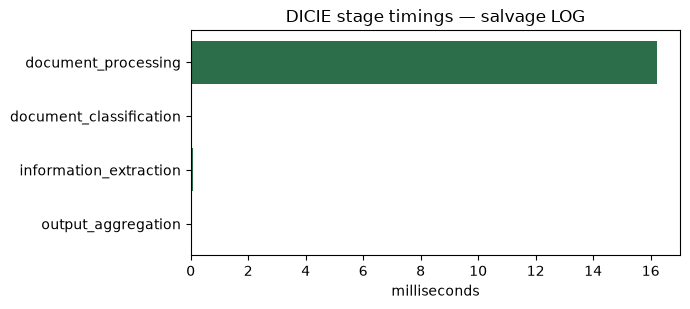

**Result:** `log` (conf=0.910) · fields={'claim_id': 'CLM-2024-100200', 'vin': '1HGCM82633A004352', 'year': '2018', 'make': 'Honda', 'model': 'Accord'} · review=False

**End-to-end response_payload**

```json
{
  "record_id": "e2e-salvage-log",
  "application": "salvage_claims",
  "document_type": "log",
  "classification_confidence": 0.91,
  "fields": {
    "claim_id": "CLM-2024-100200",
    "vin": "1HGCM82633A004352",
    "year": "2018",
    "make": "Honda",
    "model": "Accord"
  },
  "extraction_confidence": 0.85,
  "needs_human_review": false,
  "flags": [
    "extract_heuristic"
  ]
}
```

wrote /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/docie/e2e_salvage_log.json


In [14]:
pipe_salvage = DociePipeline(
    application="salvage_claims",
    cfg=cfg,
    cache_dir=CACHE / "pipeline_salvage",
    dpi=DPI,
    run_ocr=RUN_OCR,
)

pred_log = pipe_salvage.process(
    record_id="e2e-salvage-log",
    text=LOG_TEXT,
    metadata={"demo": "docie_walkthrough"},
)

timings = pred_log.stage_timings_ms
assert list(timings) == [
    "document_processing",
    "document_classification",
    "information_extraction",
    "output_aggregation",
], "Fig. 1 stage order contract"

display(Markdown("### Stage timings (ms)"))
timing_df = pd.DataFrame([{"stage": k, "ms": v} for k, v in timings.items()])
display(timing_df)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(timing_df["stage"][::-1], timing_df["ms"][::-1], color="#2c6e49")
ax.set_xlabel("milliseconds")
ax.set_title("DICIE stage timings — salvage LOG")
fig.tight_layout()
plt.show()

display(Markdown(
    f"**Result:** `{pred_log.classification.label}` "
    f"(conf={pred_log.classification.confidence:.3f}) · "
    f"fields={pred_log.extraction.fields_flat} · "
    f"review={pred_log.needs_human_review}"
))
show_json(pred_log.response_payload(), title="End-to-end response_payload")

# Persist full prediction for inspection
out_log = DEMO / "e2e_salvage_log.json"
out_log.write_text(json.dumps(pred_log.to_dict(), indent=2, default=str), encoding="utf-8")
print(f"wrote {out_log}")

### Convenience API — `process_document`

One-liner that returns a plain dict (same shape as `DociePrediction.to_dict()`).

In [15]:
result_dict = process_document(
    application="salvage_claims",
    record_id="convenience-log",
    text=LOG_TEXT,
    cfg=cfg,
    run_ocr=RUN_OCR,
)
print("keys:", sorted(result_dict.keys()))
print("document_type:", result_dict["document_type"])
print("fields:", result_dict["fields"])
print("stage_timings_ms:", result_dict["stage_timings_ms"])

INFO src.docie.pipeline: Stage 1 processing convenience-log — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify convenience-log → log (0.910)
INFO src.docie.pipeline: Stage 3 extract convenience-log — 5 field(s), backend=heuristic


keys: ['application', 'classification', 'document_type', 'extraction', 'fields', 'flags', 'needs_human_review', 'processing', 'record_id', 'stage_timings_ms']
document_type: log
fields: {'claim_id': 'CLM-2024-100200', 'vin': '1HGCM82633A004352', 'year': '2018', 'make': 'Honda', 'model': 'Accord'}
stage_timings_ms: {'document_processing': 15.06, 'document_classification': 0.05, 'information_extraction': 0.08, 'output_aggregation': 0.04}


## 10. Full orchestrator — medical bills (HCFA)

Same chain, different application profile. Labels become `hcfa` / `ub04` / `other`; extraction targets shift to claimant demographics.

INFO src.docie.pipeline: Stage 1 processing med-hcfa-001 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify med-hcfa-001 → hcfa (0.975)
INFO src.docie.pipeline: Stage 3 extract med-hcfa-001 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing med-ub04-002 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify med-ub04-002 → ub04 (0.975)
INFO src.docie.pipeline: Stage 3 extract med-ub04-002 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing med-other-003 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify med-other-003 → other (0.805)
INFO src.docie.pipeline: Stage 3 extract med-other-003 — 1 field(s), backend=heuristic


,record_id,gold,pred,cls_conf,ext_conf,claim_id,name,dob,patient_id,review,flags
0,med-hcfa-001,hcfa,hcfa,0.975,0.85,CLM-2024-551122,Jane Q Public,03/14/1988,PID-778812,False,extract_heuristic
1,med-ub04-002,ub04,ub04,0.975,0.85,CLM-2024-660033,John A Smith,1990-07-22,MRN-990011,False,extract_heuristic
2,med-other-003,other,other,0.805,0.45,NaN,Alex Rivera,NaN,NaN,True,"extract_heuristic, low_confidence_extraction, ..."


INFO src.docie.pipeline: Stage 1 processing e2e-hcfa — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify e2e-hcfa → hcfa (0.975)
INFO src.docie.pipeline: Stage 3 extract e2e-hcfa — 5 field(s), backend=heuristic


**HCFA rendered page** — `e2e-hcfa__5e557de49cedc9e1__page_000.png`

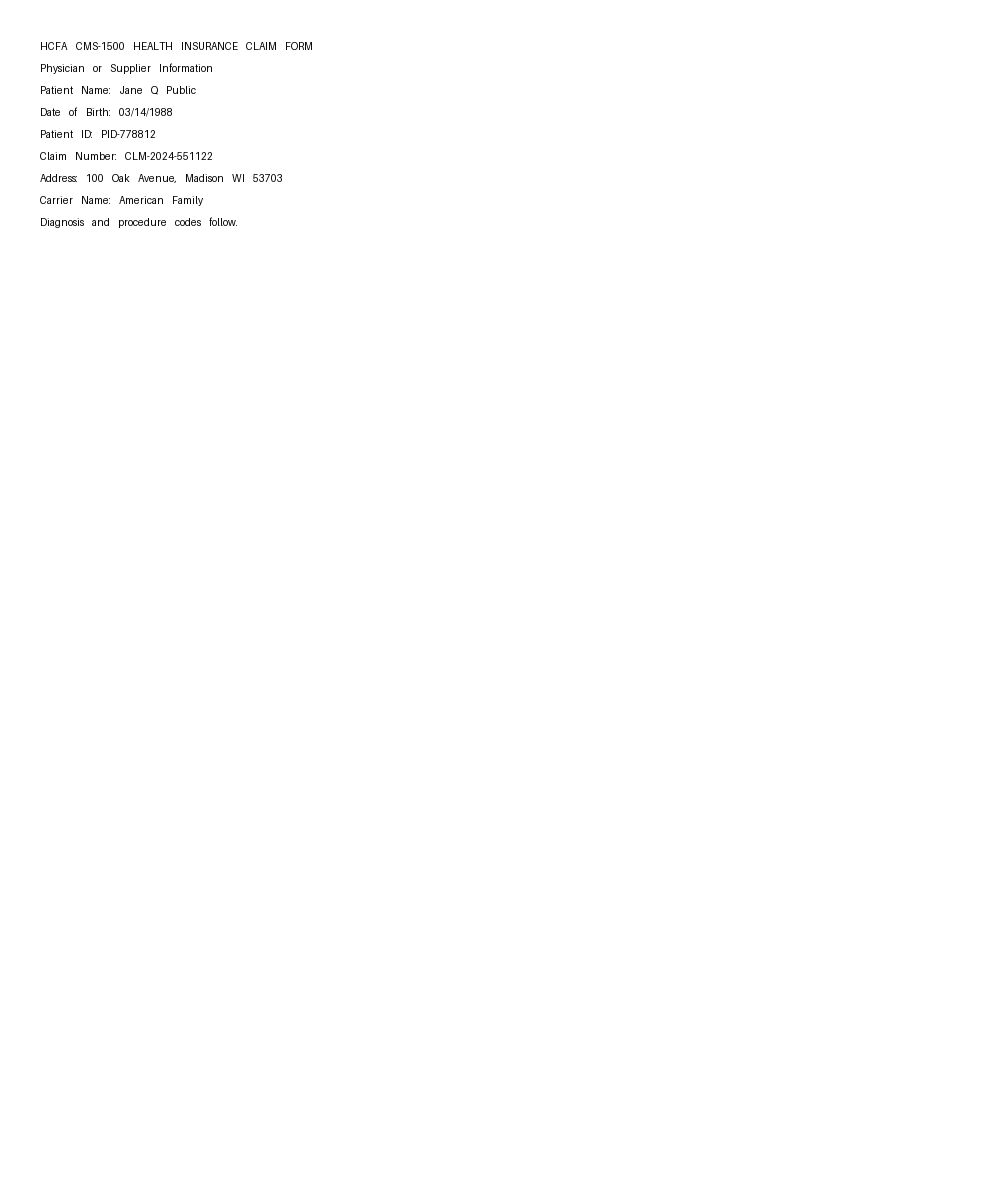

**Medical HCFA response_payload**

```json
{
  "record_id": "e2e-hcfa",
  "application": "medical_bills",
  "document_type": "hcfa",
  "classification_confidence": 0.975,
  "fields": {
    "claim_id": "CLM-2024-551122",
    "name": "Jane Q Public",
    "dob": "03/14/1988",
    "patient_id": "PID-778812",
    "address": "100 Oak Avenue, Madison WI 53703"
  },
  "extraction_confidence": 0.85,
  "needs_human_review": false,
  "flags": [
    "extract_heuristic"
  ]
}
```

In [16]:
pipe_medical = DociePipeline(
    application="medical_bills",
    cfg=cfg,
    cache_dir=CACHE / "pipeline_medical",
    dpi=DPI,
    run_ocr=RUN_OCR,
)

med_preds = []
for row in fixture_rows:
    if row["application"] != "medical_bills":
        continue
    pred = pipe_medical.process(record_id=row["record_id"], text=row["text"])
    med_preds.append(
        {
            "record_id": row["record_id"],
            "gold": row["document_type"],
            "pred": pred.classification.label,
            "cls_conf": round(pred.classification.confidence, 3),
            "ext_conf": round(pred.extraction.confidence, 3),
            "claim_id": pred.extraction.fields_flat.get("claim_id"),
            "name": pred.extraction.fields_flat.get("name"),
            "dob": pred.extraction.fields_flat.get("dob"),
            "patient_id": pred.extraction.fields_flat.get("patient_id"),
            "review": pred.needs_human_review,
            "flags": ", ".join(pred.flags) or "—",
        }
    )

med_df = pd.DataFrame(med_preds)
display(med_df)

pred_hcfa = pipe_medical.process(record_id="e2e-hcfa", text=HCFA_TEXT)
hcfa_paths = pred_hcfa.processing.get("page_image_paths") or []
if hcfa_paths and Path(hcfa_paths[0]).exists():
    display(Markdown(f"**HCFA rendered page** — `{Path(hcfa_paths[0]).name}`"))
    display(IPyImage(filename=hcfa_paths[0], width=520))
show_json(pred_hcfa.response_payload(), title="Medical HCFA response_payload")

## 11. Batch processing — `run_file`

For JSONL corpora, `run_file` (also used by `python -m src.docie --in …`) writes:

| Artifact | Contents |
|----------|----------|
| `{out}.jsonl` | Full prediction per row |
| `{out}.summary.json` | Counts, average confidences, stage chain |
| `{stem}.human_review.jsonl` | Compact payloads for rows needing review |
| provenance log | Appended under `cfg.provenance_log_path` |

Accepted row keys: `record_id` / `claim_id`, `pdf_path`, `image_path`, `source_path` / `path` / `file_path`, `text`.

> The shared fixture mixes medical + salvage rows. Below we **filter to the matching application** before each batch so classification stays on-taxonomy (running `salvage_claims` over HCFA text would correctly fall through to `other`).

INFO src.docie.pipeline: Stage 1 processing sal-log-001 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-log-001 → log (0.910)
INFO src.docie.pipeline: Stage 3 extract sal-log-001 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing sal-sales-002 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-sales-002 → sales (0.975)
INFO src.docie.pipeline: Stage 3 extract sal-sales-002 — 4 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing sal-other-003 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sal-other-003 → other (0.805)
INFO src.docie.pipeline: Stage 3 extract sal-other-003 — 0 field(s), backend=heuristic


**salvage batch summary**

```json
{
  "n": 3,
  "application": "salvage_claims",
  "chain": [
    "document_processing",
    "document_classification",
    "information_extraction",
    "output_aggregation"
  ],
  "needs_human_review": 1,
  "label_counts": {
    "log": 1,
    "sales": 1,
    "other": 1
  },
  "avg_classification_confidence": 0.8966666666666666,
  "avg_extraction_confidence": 0.6166666666666667
}
```

,record_id,document_type,cls_conf,ext_conf,fields,review,flags
0,sal-log-001,log,0.910,0.85,"{'claim_id': 'CLM-2024-100200', 'vin': '1HGCM8...",False,[extract_heuristic]
1,sal-sales-002,sales,0.975,0.75,"{'vin': '1FADP3F20EL123456', 'year': '2015', '...",False,[extract_heuristic]
2,sal-other-003,other,0.805,0.25,{},True,"[extract_heuristic, low_confidence_extraction,..."


predictions: /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/docie/batch_salvage.jsonl
summary:     /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/docie/batch_salvage.summary.json
review queue (1): /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/docie/batch_salvage.human_review.jsonl


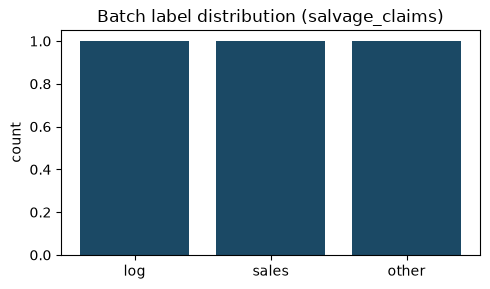

INFO src.docie.pipeline: Stage 1 processing med-hcfa-001 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify med-hcfa-001 → hcfa (0.975)
INFO src.docie.pipeline: Stage 3 extract med-hcfa-001 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing med-ub04-002 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify med-ub04-002 → ub04 (0.975)
INFO src.docie.pipeline: Stage 3 extract med-ub04-002 — 5 field(s), backend=heuristic
INFO src.docie.pipeline: Stage 1 processing med-other-003 — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify med-other-003 → other (0.805)
INFO src.docie.pipeline: Stage 3 extract med-other-003 — 1 field(s), backend=heuristic


**medical batch summary**

```json
{
  "n": 3,
  "application": "medical_bills",
  "chain": [
    "document_processing",
    "document_classification",
    "information_extraction",
    "output_aggregation"
  ],
  "needs_human_review": 1,
  "label_counts": {
    "hcfa": 1,
    "ub04": 1,
    "other": 1
  },
  "avg_classification_confidence": 0.9183333333333333,
  "avg_extraction_confidence": 0.7166666666666667
}
```

,record_id,document_type,cls_conf,fields,review
0,med-hcfa-001,hcfa,0.975,"{'claim_id': 'CLM-2024-551122', 'name': 'Jane ...",False
1,med-ub04-002,ub04,0.975,"{'claim_id': 'CLM-2024-660033', 'name': 'John ...",False
2,med-other-003,other,0.805,{'name': 'Alex Rivera'},True


In [17]:
# Write application-filtered JSONL inputs for clean batch demos
salvage_in = DEMO / "input_salvage.jsonl"
medical_in = DEMO / "input_medical.jsonl"
salvage_in.write_text(
    "\n".join(json.dumps(r) for r in fixture_rows if r["application"] == "salvage_claims") + "\n",
    encoding="utf-8",
)
medical_in.write_text(
    "\n".join(json.dumps(r) for r in fixture_rows if r["application"] == "medical_bills") + "\n",
    encoding="utf-8",
)

batch_out = DEMO / "batch_salvage.jsonl"
path = run_file(
    salvage_in,
    batch_out,
    application="salvage_claims",
    cfg=cfg,
    run_ocr=RUN_OCR,
)

batch_rows = load_jsonl(path)
summary = read_json(path.with_suffix(".summary.json"))
review_path = path.with_name(path.stem + ".human_review.jsonl")
review_rows = load_jsonl(review_path) if review_path.exists() else []

show_json(summary, title="salvage batch summary")

batch_df = pd.DataFrame(
    [
        {
            "record_id": r["record_id"],
            "document_type": r["document_type"],
            "cls_conf": round(r["classification"]["confidence"], 3),
            "ext_conf": round(r["extraction"]["confidence"], 3),
            "fields": {k: v for k, v in r["fields"].items() if v},
            "review": r["needs_human_review"],
            "flags": r["flags"],
        }
        for r in batch_rows
    ]
)
display(batch_df)

print(f"predictions: {path}")
print(f"summary:     {path.with_suffix('.summary.json')}")
print(f"review queue ({len(review_rows)}): {review_path}")

label_counts = Counter(r["document_type"] for r in batch_rows)
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(list(label_counts.keys()), list(label_counts.values()), color="#1b4965")
ax.set_ylabel("count")
ax.set_title("Batch label distribution (salvage_claims)")
fig.tight_layout()
plt.show()

# Mirror for medical_bills
med_batch_out = DEMO / "batch_medical.jsonl"
med_path = run_file(
    medical_in,
    med_batch_out,
    application="medical_bills",
    cfg=cfg,
    run_ocr=RUN_OCR,
)
med_summary = read_json(med_path.with_suffix(".summary.json"))
show_json(med_summary, title="medical batch summary")
med_batch_df = pd.DataFrame(
    [
        {
            "record_id": r["record_id"],
            "document_type": r["document_type"],
            "cls_conf": round(r["classification"]["confidence"], 3),
            "fields": {k: v for k, v in r["fields"].items() if v},
            "review": r["needs_human_review"],
        }
        for r in load_jsonl(med_path)
    ]
)
display(med_batch_df)


### PDF end-to-end through the orchestrator

Reuse the 2-page PDF from Stage 1 to show the full chain on a file path (not just text).

In [18]:
pred_pdf = pipe_salvage.process(
    record_id="e2e-pdf-log",
    pdf_path=pdf_path,
)

display(Markdown(
    f"PDF → **{pred_pdf.classification.label}** "
    f"(conf={pred_pdf.classification.confidence:.3f}, "
    f"backend={pred_pdf.classification.backend}) · "
    f"n_pages={pred_pdf.processing['n_pages']} · "
    f"ocr={pred_pdf.processing['ocr_backends']}"
))
show_json(pred_pdf.response_payload(), title="PDF response_payload")
show_json(pred_pdf.extraction.fields_flat, title="Extracted fields")

INFO src.docie.pipeline: Stage 1 processing e2e-pdf-log — 2 page(s), kind=pdf
INFO src.docie.pipeline: Stage 2 classify e2e-pdf-log → log (0.820)
INFO src.docie.pipeline: Stage 3 extract e2e-pdf-log — 5 field(s), backend=heuristic


PDF → **log** (conf=0.820, backend=heuristic_text) · n_pages=2 · ocr=['pymupdf_text']

**PDF response_payload**

```json
{
  "record_id": "e2e-pdf-log",
  "application": "salvage_claims",
  "document_type": "log",
  "classification_confidence": 0.8200000000000001,
  "fields": {
    "claim_id": "CLM-PDF-2024-77",
    "vin": "1HGCM82633A004352",
    "year": "2019",
    "make": "Toyota",
    "model": "Camry"
  },
  "extraction_confidence": 0.85,
  "needs_human_review": false,
  "flags": [
    "extract_heuristic"
  ]
}
```

**Extracted fields**

```json
{
  "claim_id": "CLM-PDF-2024-77",
  "vin": "1HGCM82633A004352",
  "year": "2019",
  "make": "Toyota",
  "model": "Camry"
}
```

## 12. Downstream sink & optional model backends

### Downstream sink

Pass a callable to `DociePipeline(..., downstream_sink=fn)`. Every `process` call will invoke `push_downstream`, which delivers `response_payload()` to your webhook / queue / claim-center updater.

In [19]:
sunk: list[dict] = []

pipe_with_sink = DociePipeline(
    application="salvage_claims",
    cfg=cfg,
    cache_dir=CACHE / "pipeline_sink",
    run_ocr=RUN_OCR,
    downstream_sink=sunk.append,
)
pred_sink = pipe_with_sink.process(record_id="sink-demo", text=LOG_TEXT)
payload = push_downstream(pred_sink)  # also returns the payload without a sink

print(f"sink received {len(sunk)} payload(s)")
show_json(sunk[0], title="Payload delivered to downstream_sink")
assert sunk[0]["document_type"] == "log"
assert payload["fields"]["vin"]

INFO src.docie.pipeline: Stage 1 processing sink-demo — 1 page(s), kind=text
INFO src.docie.pipeline: Stage 2 classify sink-demo → log (0.910)
INFO src.docie.pipeline: Stage 3 extract sink-demo — 5 field(s), backend=heuristic


sink received 1 payload(s)


**Payload delivered to downstream_sink**

```json
{
  "record_id": "sink-demo",
  "application": "salvage_claims",
  "document_type": "log",
  "classification_confidence": 0.91,
  "fields": {
    "claim_id": "CLM-2024-100200",
    "vin": "1HGCM82633A004352",
    "year": "2018",
    "make": "Honda",
    "model": "Accord"
  },
  "extraction_confidence": 0.85,
  "needs_human_review": false,
  "flags": [
    "extract_heuristic"
  ]
}
```

### Optional neural backends

| Backend | How to enable | Notes |
|---------|---------------|-------|
| ViT page classifier | `DociePipeline(..., vit_model_dir=Path(...))` | Needs `config.json` + labels intersecting the app taxonomy; blended with heuristics |
| LayoutLM extractor | weights under `models/extractor` or `models/extractor_smoke` | Auto-discovered; field names must match `extraction_fields` |
| OCR | `RUN_OCR=True` + `pip install -e ".[ocr]"` + Tesseract | Word boxes feed LayoutLM-style extractors |

The cell below reports what is available locally (smoke weights from the other pipeline notebook do **not** match medical/salvage labels, so heuristics remain the active path).

In [20]:
candidates = [
    cfg.models_dir / "extractor",
    cfg.models_dir / "extractor_smoke",
    REPO_ROOT / "data" / "notebook_demo" / "models" / "extractor_smoke",
    REPO_ROOT / "data" / "notebook_demo" / "models" / "classifier_smoke",
]

avail = []
for path in candidates:
    cfg_json = path / "config.json"
    labels = path / "label2id.json"
    avail.append(
        {
            "path": str(path.relative_to(REPO_ROOT)) if path.is_relative_to(REPO_ROOT) else str(path),
            "exists": path.exists(),
            "has_config": cfg_json.exists(),
            "has_label2id": labels.exists(),
            "label_sample": (
                list(json.loads(labels.read_text()).keys())[:6] if labels.exists() else []
            ),
        }
    )

display(pd.DataFrame(avail))
print(
    "Default DociePipeline extractor_dir:",
    pipe_salvage.extractor_dir,
)
print(
    "Heuristic path is sufficient for this walkthrough; "
    "point vit_model_dir / extractor_dir at matching weights to activate neural backends."
)

,path,exists,has_config,has_label2id,label_sample
0,models/extractor,False,False,False,[]
1,models/extractor_smoke,False,False,False,[]
2,data/notebook_demo/models/extractor_smoke,True,True,True,"[O, B-claim_id, I-claim_id, B-policy_number, I..."
3,data/notebook_demo/models/classifier_smoke,True,True,True,"[application_commercial, application_personal,..."


Default DociePipeline extractor_dir: None
Heuristic path is sufficient for this walkthrough; point vit_model_dir / extractor_dir at matching weights to activate neural backends.


### Optional — FastAPI serve shape

Not started from this notebook (keeps the walkthrough offline), but the paper §VI serving surface is:

```bash
pip install -e ".[serve]"
python -m src.docie.serve --application salvage_claims --port 8080
```

| Endpoint | Body |
|----------|------|
| `GET /health` | status + available applications |
| `POST /v1/predict` | multipart file + `application_name` |
| `POST /v1/predict/text` | JSON `{text, application, record_id}` |

CLI one-shot (same orchestrator as this notebook):

```bash
python -m src.docie --application salvage_claims --text "LETTER OF GUARANTEE..." --response-only
python -m src.docie --application medical_bills --pdf path/to/bill.pdf
python -m src.docie --application salvage_claims \
  --in tests/fixtures/sample_docie_documents.jsonl \
  --out data/pipeline/docie/salvage_demo.jsonl
```

## 13. DICIE vs the memo-chain orchestrator

This repo has **two** inference paths. Use the table below to choose:

| Concern | `src/docie/` (this notebook) | `src/pipeline/` |
|---------|------------------------------|-----------------|
| Ordering | process → classify → extract → respond | markdown → classify → extract → vision → summarize |
| Primary signal | page images + OCR | structured markdown for LLM context |
| Applications | medical bills, salvage claims (+ acord) | ACORD intake + adjuster memo |
| Output | classification + fields (+ review flag) | classification + fields + memo |
| Keys / GPU | none for heuristics | OpenRouter etc. for LLM stages |

See [`notebooks/pipeline_walkthrough.ipynb`](pipeline_walkthrough.ipynb) for the markdown / training / memo path.

## 14. Recap — what this walkthrough exercised

1. Loaded application profiles from taxonomy YAML  
2. Inspected the six-document fixture corpus  
3. Ran Stage 1 on **text** (rendered page PNG) and a **2-page PDF**  
4. Classified pages with heuristics and aggregated with prefer-non-`other`  
5. Extracted medical + salvage fields via `heuristic_extract` / `extract_information`  
6. Aggregated into `DociePrediction` with review routing + dual payload shapes  
7. Drove the full `DociePipeline` for salvage LOG and medical HCFA/UB04/other  
8. Batched JSONL via `run_file` (predictions + summary + human-review queue)  
9. Demonstrated a downstream sink and inspected optional model weight paths  

All demo artifacts land under:

In [21]:
artifacts = sorted(p for p in DEMO.rglob("*") if p.is_file())
art_df = pd.DataFrame(
    [
        {
            "path": str(p.relative_to(REPO_ROOT)),
            "kb": round(p.stat().st_size / 1024, 1),
        }
        for p in artifacts
    ]
)
display(art_df)
print(f"{len(art_df)} files under {DEMO.relative_to(REPO_ROOT)}")

display(Markdown(
    "### Next steps\n"
    "- Point `vit_model_dir` / `extractor_dir` at application-matched weights\n"
    "- Enable `RUN_OCR = True` for scanned page images\n"
    "- Serve with `python -m src.docie.serve` for the REST surface\n"
    "- Read `docs/docie_pipeline.md` for production CLI recipes"
))

,path,kb
0,data/notebook_demo/docie/batch_medical.human_r...,0.4
1,data/notebook_demo/docie/batch_medical.jsonl,4.4
2,data/notebook_demo/docie/batch_medical.summary...,0.4
3,data/notebook_demo/docie/batch_salvage.human_r...,0.4
4,data/notebook_demo/docie/batch_salvage.jsonl,4.1
5,data/notebook_demo/docie/batch_salvage.summary...,0.4
6,data/notebook_demo/docie/cache/pages/walkthrou...,18.2
7,data/notebook_demo/docie/cache/pages/walkthrou...,12.7
8,data/notebook_demo/docie/cache/pages/walkthrou...,71.4
9,data/notebook_demo/docie/cache/pages/walkthrou...,33.1


22 files under data/notebook_demo/docie


### Next steps
- Point `vit_model_dir` / `extractor_dir` at application-matched weights
- Enable `RUN_OCR = True` for scanned page images
- Serve with `python -m src.docie.serve` for the REST surface
- Read `docs/docie_pipeline.md` for production CLI recipes